# DermaMNIST — Exploratory Data Analysis

**Progetto:** pipeline agentica per classificazione e data augmentation di lesioni cutanee pigmentate (WP1 / D1).

**Obiettivo di questa EDA.** Caratterizzare il dataset *prima* di progettare il classificatore, rispondendo a
quattro domande operative:

1. **Numerosità** — quante immagini, come sono distribuite fra `train` / `val` / `test`?
2. **Classi** — quali sono, quanto sono sbilanciate, lo sbilanciamento è coerente fra gli split?
3. **Immagini** — che formato, che dinamica, che statistiche cromatiche? Le classi sono separabili con
   feature elementari o serve una rappresentazione appresa?
4. **Qualità** — duplicati, near-duplicate, leakage fra split, criticità note in letteratura.

**Tracciabilità sui requisiti (WP1-D1).** Le sezioni coprono direttamente:

| Requisito | Contenuto | Sezione |
|---|---|---|
| FR-D1 | split ufficiali train/val/test | §1–§2 |
| FR-D2 | duplicati, leakage, mislabeling | §7 |
| FR-D3 | costanti di normalizzazione condivise | §3, §9 |
| FR-D4 | caratterizzazione ed esposizione dello sbilanciamento | §2, §9 |
| FR-C1/C2 | 7 classi, baseline probabilistica di riferimento | §8 |
| FR-A1 | classi sotto-rappresentate da riequilibrare | §2, §9 |

L'output finale (§9) è un file JSON con costanti di normalizzazione, conteggi e class weight,
consumabile dagli stage a valle della pipeline.

---
## 0. Setup

Dipendenze: `medmnist`, `numpy`, `pandas`, `matplotlib`, `scikit-learn`.
Il file `dermamnist.npz` (~19 MB) viene scaricato una sola volta in `~/.medmnist/`.

In [2]:
import os, json, hashlib, itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import medmnist
from medmnist import INFO

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

OUT_DIR = "eda_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print("medmnist", medmnist.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)

medmnist 3.0.2 | numpy 2.5.2 | pandas 3.0.5


---
## 1. Caricamento e struttura del dataset

DermaMNIST deriva da **HAM10000** (Tschandl et al., 2018): immagini dermatoscopiche multi-sorgente di
lesioni pigmentate, originariamente `3×600×450`, ridimensionate a `3×28×28`. Lo split ufficiale MedMNIST
è **7:1:2** e va usato così com'è (FR-D1) per garantire confrontabilità con il benchmark.

Carichiamo direttamente l'archivio `.npz` per avere accesso ai tensori grezzi `uint8`, senza le
trasformazioni applicate dalla classe `DermaMNIST` di PyTorch.

In [3]:
# Scarica (se necessario) tramite l'API ufficiale, poi lavora sull'.npz grezzo
DATA_FLAG = "dermamnist"
info = INFO[DATA_FLAG]
ROOT = os.path.expanduser("~/.medmnist")
NPZ_PATH = os.path.join(ROOT, f"{DATA_FLAG}.npz")

if not os.path.exists(NPZ_PATH):
    getattr(medmnist, info["python_class"])(split="train", download=True)

npz = np.load(NPZ_PATH)

SPLITS = ["train", "val", "test"]
X = {s: npz[f"{s}_images"] for s in SPLITS}          # (N, 28, 28, 3) uint8
y = {s: npz[f"{s}_labels"].ravel() for s in SPLITS}  # (N,) uint8

CLASS_NAMES = [info["label"][str(k)] for k in range(len(info["label"]))]
# Sigle HAM10000, utili per assi e legende compatte
CLASS_ABBR = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
N_CLASSES = len(CLASS_NAMES)

print("Task:", info["task"], "| n_channels:", info["n_channels"], "| n_classes:", N_CLASSES)
print("\nDescrizione:", info["description"])
print("\n--- Struttura dei tensori ---")
for s in SPLITS:
    print(f"{s:>5}: images {str(X[s].shape):<20} {X[s].dtype}   labels {str(y[s].shape):<10} {y[s].dtype}")

Task: multi-class | n_channels: 3 | n_classes: 7

Descrizione: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.

--- Struttura dei tensori ---
train: images (7007, 28, 28, 3)    uint8   labels (7007,)    uint8
  val: images (1003, 28, 28, 3)    uint8   labels (1003,)    uint8
 test: images (2005, 28, 28, 3)    uint8   labels (2005,)    uint8


In [4]:
# Mappa delle etichette
pd.DataFrame({
    "id": range(N_CLASSES),
    "abbr": CLASS_ABBR,
    "nome": CLASS_NAMES,
})

,id,abbr,nome
0,0,akiec,actinic keratoses and intraepithelial carcinoma
1,1,bcc,basal cell carcinoma
2,2,bkl,benign keratosis-like lesions
3,3,df,dermatofibroma
4,4,mel,melanoma
5,5,nv,melanocytic nevi
6,6,vasc,vascular lesions


> **Nota.** MedMNIST fornisce anche varianti a risoluzione maggiore (64, 128, 224 px) dello stesso split.
> A 28×28 gran parte della struttura dermatoscopica fine (rete pigmentaria, globuli, strie) è distrutta:
> è una limitazione da tenere presente nell'interpretare le performance e un possibile asse di miglioramento
> (FR-C4).

---
## 2. Numerosità e distribuzione delle classi

Le due domande chiave per il task di classificazione:
il dataset è **grande abbastanza**? è **sbilanciato**? e lo sbilanciamento è **stabile** fra gli split
(se non lo fosse, val/test non sarebbero stimatori affidabili delle performance)?

In [5]:
n_tot = sum(len(y[s]) for s in SPLITS)

split_tbl = pd.DataFrame(
    [{"split": s, "n_immagini": len(y[s]), "quota_%": round(100 * len(y[s]) / n_tot, 2)} for s in SPLITS]
    + [{"split": "TOTALE", "n_immagini": n_tot, "quota_%": 100.0}]
)
split_tbl

,split,n_immagini,quota_%
0,train,7007,69.97
1,val,1003,10.01
2,test,2005,20.02
3,TOTALE,10015,100.00


In [6]:
# Conteggi per classe e per split
counts = pd.DataFrame(
    {s: [int((y[s] == k).sum()) for k in range(N_CLASSES)] for s in SPLITS},
    index=pd.Index(CLASS_ABBR, name="classe"),
)
counts["totale"] = counts.sum(axis=1)
counts["quota_%"] = (100 * counts["totale"] / n_tot).round(2)
counts["nome"] = CLASS_NAMES

display(counts)

imb = counts["totale"].max() / counts["totale"].min()
print(f"\nClasse maggioritaria : {counts['totale'].idxmax()} "
      f"({counts['totale'].max()} img, {counts['quota_%'].max():.1f}%)")
print(f"Classe minoritaria   : {counts['totale'].idxmin()} "
      f"({counts['totale'].min()} img, {counts['quota_%'].min():.1f}%)")
print(f"Imbalance ratio (max/min): {imb:.1f}x")

,train,val,test,totale,quota_%,nome
classe,,,,,,
akiec,228,33,66,327,3.27,actinic keratoses and intraepithelial carcinoma
bcc,359,52,103,514,5.13,basal cell carcinoma
bkl,769,110,220,1099,10.97,benign keratosis-like lesions
df,80,12,23,115,1.15,dermatofibroma
mel,779,111,223,1113,11.11,melanoma
nv,4693,671,1341,6705,66.95,melanocytic nevi
vasc,99,14,29,142,1.42,vascular lesions



Classe maggioritaria : nv (6705 img, 67.0%)
Classe minoritaria   : df (115 img, 1.1%)
Imbalance ratio (max/min): 58.3x


In [7]:
# Proporzioni per split: verifica che lo split preservi la distribuzione di classe
props = pd.DataFrame(
    {s: [100 * (y[s] == k).mean() for k in range(N_CLASSES)] for s in SPLITS},
    index=pd.Index(CLASS_ABBR, name="classe"),
).round(2)

drift = pd.DataFrame(
    [{"coppia": f"{a} vs {b}", "max_diff_pp": round(float((props[a] - props[b]).abs().max()), 2)}
     for a, b in itertools.combinations(SPLITS, 2)]
)
display(props)
display(drift)

,train,val,test
classe,,,
akiec,3.25,3.29,3.29
bcc,5.12,5.18,5.14
bkl,10.97,10.97,10.97
df,1.14,1.20,1.15
mel,11.12,11.07,11.12
nv,66.98,66.90,66.88
vasc,1.41,1.40,1.45


,coppia,max_diff_pp
0,train vs val,0.08
1,train vs test,0.10
2,val vs test,0.05


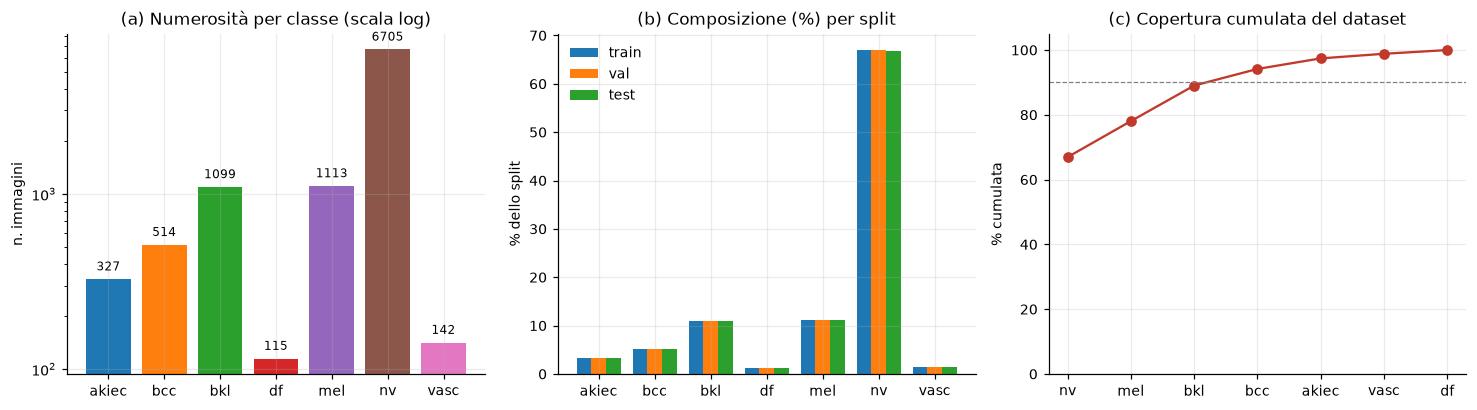

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
palette = plt.cm.tab10(np.arange(N_CLASSES))

# (a) conteggi assoluti, scala log per rendere leggibili le classi rare
ax = axes[0]
ax.bar(CLASS_ABBR, counts["totale"], color=palette)
ax.set_yscale("log")
ax.set_title("(a) Numerosità per classe (scala log)")
ax.set_ylabel("n. immagini")
for i, v in enumerate(counts["totale"]):
    ax.text(i, v * 1.12, str(v), ha="center", fontsize=8)

# (b) composizione percentuale per split
ax = axes[1]
w = 0.26
xpos = np.arange(N_CLASSES)
for i, s in enumerate(SPLITS):
    ax.bar(xpos + (i - 1) * w, props[s], width=w, label=s)
ax.set_xticks(xpos, CLASS_ABBR)
ax.set_title("(b) Composizione (%) per split")
ax.set_ylabel("% dello split")
ax.legend(frameon=False)

# (c) squilibrio cumulato
ax = axes[2]
order = counts["totale"].sort_values(ascending=False)
cum = 100 * order.cumsum() / order.sum()
ax.plot(range(1, N_CLASSES + 1), cum, "o-", color="#c0392b")
ax.axhline(90, ls="--", lw=0.8, color="grey")
ax.set_xticks(range(1, N_CLASSES + 1), order.index)
ax.set_title("(c) Copertura cumulata del dataset")
ax.set_ylabel("% cumulata")
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

### Cosa emerge

* **10.015 immagini** in totale: `train` 7.007 (69,97%), `val` 1.003 (10,01%), `test` 2.005 (20,02%) —
  lo split 7:1:2 dichiarato è rispettato.
* **Sbilanciamento severo**: `nv` (nei melanocitici, benigni) copre da sola il **67%** del dataset,
  mentre `df` (dermatofibroma) si ferma a **115 immagini (1,15%)**. **Imbalance ratio ≈ 58:1**.
* Le prime due classi (`nv`, `mel`) coprono ~78% del dataset; le quattro classi più rare insieme ~11%.
* **Lo split è stratificato**: la differenza massima di proporzione fra due split qualsiasi è **≤ 0,09 punti
  percentuali**. `val` e `test` sono quindi rappresentativi della distribuzione di `train`.

**Conseguenze dirette sul task di classificazione:**

| Problema | Conseguenza | Contromisura |
|---|---|---|
| 67% di una sola classe | l'accuracy è ingannevole: predire sempre `nv` dà **0,669** sul test | usare **balanced accuracy, macro-F1, AUC-OvR**, matrice di confusione |
| classi rare (`df`: 80 immagini in train) | varianza altissima delle metriche per-classe, rischio che il modello non le apprenda | class weight / focal loss, oversampling, **augmentation mirata (FR-A1)** |
| `df` in `val` ha **12** immagini | una singola immagine vale 8,3 punti di recall: model selection instabile | selezionare su metriche aggregate, valutare **cross-validation** o val set allargato |
| il test set eredita lo stesso sbilanciamento | intervalli di confidenza larghi sulle classi rare | riportare **CI bootstrap** per-classe, non solo il punto stima |

> ⚠️ Rilievo clinico: la classe `mel` (melanoma, 11,1%) è quella a maggior costo di errore — un falso
> negativo è potenzialmente letale. La metrica di progetto dovrà pesare **recall/sensibilità su `mel`**
> più dell'accuracy globale.

---
## 3. Caratteristiche delle immagini: formato e dinamica

Prima di ogni statistica derivata, verifichiamo le proprietà di base del tensore: tipo, range,
presenza di valori degeneri (immagini costanti, canali saturi, pixel mancanti).

In [9]:
X_all = np.concatenate([X[s] for s in SPLITS], axis=0)
y_all = np.concatenate([y[s] for s in SPLITS], axis=0)
split_of = np.concatenate([np.full(len(y[s]), s) for s in SPLITS])

print(f"Shape complessiva : {X_all.shape}  (N, H, W, C)")
print(f"Dtype             : {X_all.dtype}   range osservato: [{X_all.min()}, {X_all.max()}]")
print(f"Memoria           : {X_all.nbytes / 1e6:.1f} MB (uint8) -> {X_all.nbytes * 4 / 1e6:.1f} MB in float32")
print(f"Valori NaN/inf    : {np.isnan(X_all.astype(np.float32)).sum()} / {np.isinf(X_all.astype(np.float32)).sum()}")

Xf = X_all.astype(np.float32) / 255.0   # [0,1]

# immagini degeneri
std_per_img = Xf.reshape(len(Xf), -1).std(axis=1)
print(f"\nImmagini costanti (std=0)          : {(std_per_img == 0).sum()}")
print(f"Immagini quasi costanti (std<0.01) : {(std_per_img < 0.01).sum()}")
print(f"Immagini con pixel saturi a 255    : {(X_all.reshape(len(X_all), -1).max(1) == 255).mean() * 100:.1f}%")
print(f"Immagini con pixel a 0             : {(X_all.reshape(len(X_all), -1).min(1) == 0).mean() * 100:.1f}%")

Shape complessiva : (10015, 28, 28, 3)  (N, H, W, C)
Dtype             : uint8   range osservato: [0, 255]
Memoria           : 23.6 MB (uint8) -> 94.2 MB in float32
Valori NaN/inf    : 0 / 0

Immagini costanti (std=0)          : 0
Immagini quasi costanti (std<0.01) : 0
Immagini con pixel saturi a 255    : 9.3%
Immagini con pixel a 0             : 4.0%


In [10]:
# Statistiche per canale, globali e per split -> costanti di normalizzazione (FR-D3).
# float64: su ~2e7 valori l'accumulo in float32 introduce errori nella terza cifra decimale.
def channel_stats(arr):
    a = arr.astype(np.float64) / 255.0
    return a.mean(axis=(0, 1, 2)), a.std(axis=(0, 1, 2))

rows = []
for s in SPLITS + ["GLOBALE"]:
    m, sd = channel_stats(X_all if s == "GLOBALE" else X[s])
    rows.append({"split": s,
                 **{f"mean_{c}": round(float(m[i]), 4) for i, c in enumerate("RGB")},
                 **{f"std_{c}": round(float(sd[i]), 4) for i, c in enumerate("RGB")}})
chan_tbl = pd.DataFrame(rows)
display(chan_tbl)

# Le costanti da usare a valle vanno calcolate SOLO sul train (evita leakage di statistiche)
TRAIN_MEAN, TRAIN_STD = channel_stats(X["train"])
print("\nNormalizzazione da applicare (stimata sul solo TRAIN):")
print("  mean =", np.round(TRAIN_MEAN, 4).tolist())
print("  std  =", np.round(TRAIN_STD, 4).tolist())

,split,mean_R,mean_G,mean_B,std_R,std_G,std_B
0,train,0.7631,0.5381,0.5614,0.1366,0.1543,0.1692
1,val,0.7658,0.5422,0.5664,0.1343,0.1513,0.1661
2,test,0.7646,0.5370,0.5593,0.1404,0.1545,0.1695
3,GLOBALE,0.7637,0.5383,0.5615,0.1371,0.1540,0.1690



Normalizzazione da applicare (stimata sul solo TRAIN):
  mean = [0.7631, 0.5381, 0.5614]
  std  = [0.1366, 0.1543, 0.1692]


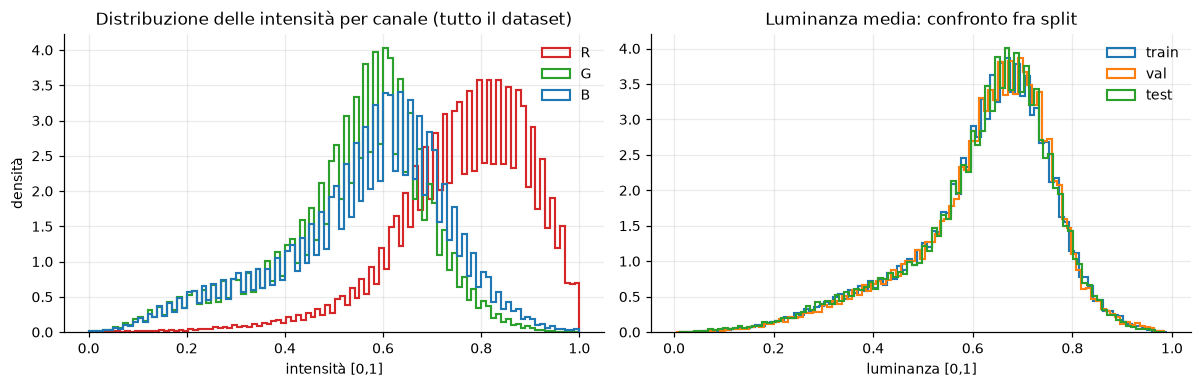

In [11]:
# Istogrammi di intensità per canale
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

colors = {"R": "#d62728", "G": "#2ca02c", "B": "#1f77b4"}
ax = axes[0]
for i, c in enumerate("RGB"):
    ax.hist(Xf[..., i].ravel()[::37], bins=100, histtype="step", lw=1.4, color=colors[c], label=c, density=True)
ax.set_title("Distribuzione delle intensità per canale (tutto il dataset)")
ax.set_xlabel("intensità [0,1]"); ax.set_ylabel("densità"); ax.legend(frameon=False)

ax = axes[1]
for s in SPLITS:
    ax.hist((X[s].astype(np.float32) / 255.0).mean(axis=3).ravel()[::17], bins=100,
            histtype="step", lw=1.4, label=s, density=True)
ax.set_title("Luminanza media: confronto fra split")
ax.set_xlabel("luminanza [0,1]"); ax.legend(frameon=False)

plt.tight_layout(); plt.show()

### Cosa emerge

* Formato uniforme: **28×28×3, `uint8`, range pieno [0, 255]**, nessun NaN, nessuna immagine degenere
  o costante. Il dataset è "pulito" dal punto di vista del formato — nessun preprocessing di sanitizzazione
  necessario.
* **Forte dominanza del canale rosso**: media globale **R=0,764 / G=0,538 / B=0,562**, ben lontana dal
  grigio neutro. È l'atteso per immagini di cute; il canale rosso è anche il più compresso in dinamica
  (std 0,137 contro 0,154 e 0,169), quindi porta meno informazione discriminante dei canali G e B.
* Le statistiche per canale sono **quasi identiche fra i tre split** (scarto massimo 0,007 sulle medie,
  0,006 sulle deviazioni standard): nessun covariate shift cromatico fra train, val e test.
* Il **9,3%** delle immagini contiene pixel saturi a 255 e il **4,0%** pixel a 0: clipping presente ma
  contenuto, tipico di riflessi speculari e vignettatura del dermatoscopio.
* Il dataset è piccolo in memoria (**23,6 MB** in `uint8`): sta interamente in RAM, quindi il data loading
  non sarà mai il collo di bottiglia e si può fare augmentation on-the-fly senza costi di I/O.

> **Decisione operativa (FR-D3):** normalizzare con `mean=[0.7631, 0.5381, 0.5614]`,
> `std=[0.1366, 0.1543, 0.1692]` — statistiche stimate **solo sul train**, per non far filtrare
> informazione di val/test nel preprocessing. In caso di transfer learning da ImageNet, valutare invece
> le costanti ImageNet per coerenza con i pesi pre-addestrati (FR-C3).

---
## 4. Statistiche fotometriche per classe

Le classi si distinguono per qualcosa di misurabile con feature elementari (luminosità, contrasto,
saturazione, tinta)? La risposta stabilisce **quanto lavoro deve fare il modello**: se semplici statistiche
globali separassero le classi, un classificatore lineare basterebbe.

In [12]:
# Feature fotometriche a basso livello, una riga per immagine
gray = Xf.mean(axis=3)                                   # luminanza
mx, mn = Xf.max(axis=3), Xf.min(axis=3)
sat = np.where(mx > 0, (mx - mn) / np.maximum(mx, 1e-6), 0.0)   # saturazione HSV

feat = pd.DataFrame({
    "classe": [CLASS_ABBR[k] for k in y_all],
    "split": split_of,
    "luminosita": gray.mean(axis=(1, 2)),
    "contrasto": gray.std(axis=(1, 2)),
    "saturazione": sat.mean(axis=(1, 2)),
    "R": Xf[..., 0].mean(axis=(1, 2)),
    "G": Xf[..., 1].mean(axis=(1, 2)),
    "B": Xf[..., 2].mean(axis=(1, 2)),
})
# Contrasto centro/bordo: la lesione occupa il centro dell'immagine dermatoscopica
c = gray[:, 9:19, 9:19].mean(axis=(1, 2))
b = (gray.sum(axis=(1, 2)) - gray[:, 9:19, 9:19].sum(axis=(1, 2))) / (28 * 28 - 100)
feat["centro_meno_bordo"] = c - b

summary = feat.groupby("classe")[["luminosita", "contrasto", "saturazione", "R", "G", "B", "centro_meno_bordo"]].mean()
summary = summary.reindex(CLASS_ABBR).round(3)
summary.insert(0, "n", feat.groupby("classe").size().reindex(CLASS_ABBR))
summary

,n,luminosita,contrasto,saturazione,R,G,B,centro_meno_bordo
classe,,,,,,,,
akiec,327,0.662,0.079,0.269,0.788,0.588,0.610,-0.067
bcc,514,0.678,0.073,0.223,0.776,0.615,0.643,-0.074
bkl,1099,0.611,0.091,0.241,0.707,0.549,0.577,-0.107
df,115,0.667,0.073,0.263,0.788,0.590,0.623,-0.073
mel,1113,0.597,0.131,0.271,0.699,0.534,0.559,-0.188
nv,6705,0.619,0.112,0.347,0.781,0.527,0.548,-0.178
vasc,142,0.662,0.100,0.273,0.776,0.575,0.633,-0.162


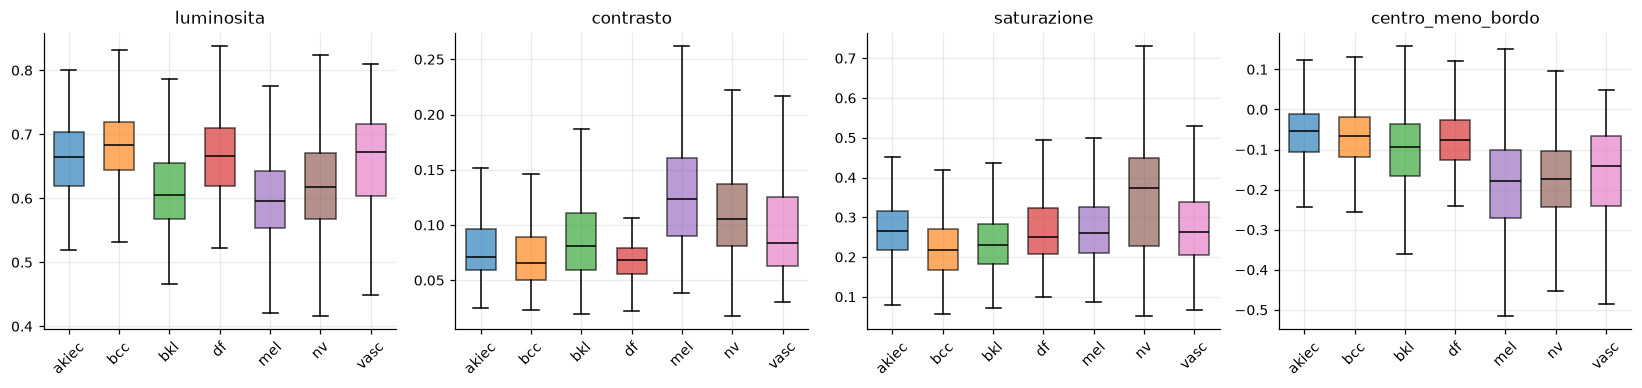

In [13]:
metrics = ["luminosita", "contrasto", "saturazione", "centro_meno_bordo"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, m in zip(axes, metrics):
    data = [feat.loc[feat.classe == c, m].values for c in CLASS_ABBR]
    bp = ax.boxplot(data, tick_labels=CLASS_ABBR, showfliers=False, patch_artist=True, widths=0.6)
    for patch, col in zip(bp["boxes"], palette):
        patch.set_facecolor(col); patch.set_alpha(0.65)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [14]:
# Quanto separano davvero queste 7 feature? Effect size (eta^2) per ciascuna
from sklearn.feature_selection import f_classif

cols = ["luminosita", "contrasto", "saturazione", "R", "G", "B", "centro_meno_bordo"]
F, p = f_classif(feat[cols].values, y_all)
eta2 = (F * (N_CLASSES - 1)) / (F * (N_CLASSES - 1) + (len(y_all) - N_CLASSES))
pd.DataFrame({"feature": cols, "F": F.round(1), "p_value": p, "eta2 (var. spiegata)": eta2.round(4)}) \
  .sort_values("eta2 (var. spiegata)", ascending=False).reset_index(drop=True)

,feature,F,p_value,eta2 (var. spiegata)
0,saturazione,252.0,3.890702e-301,0.1312
1,R,223.5,8.562192e-269,0.1182
2,centro_meno_bordo,192.5,6.293071e-233,0.1035
3,contrasto,177.6,1.390890e-215,0.0962
4,B,118.9,1.220560e-145,0.0665
5,G,112.0,2.947730e-137,0.0629
6,luminosita,101.2,4.095741e-124,0.0572


### Cosa emerge

* Le differenze fra classi esistono ma sono **piccole rispetto alla varianza interna**:
  * `mel` (melanoma) è la classe **più scura (0,597)** e con **contrasto più alto (0,131)** — coerente con la
    semeiotica clinica: lesioni disomogenee, policromatiche, a bordi irregolari;
  * `nv` (nei) ha la **saturazione più alta (0,347)**, colore uniforme;
  * `bcc` e `df` sono le più **chiare e a basso contrasto** (0,678 / 0,073), difficilmente distinguibili tra
    loro con statistiche globali.
  * `mel` ha anche il **contrasto centro-bordo più marcato (-0,188)**: lesione scura su cute chiara.
* L'analisi dell'effect size conferma il quadro: la feature più informativa è la **saturazione
  (η² = 0,131)**, seguita da canale R (0,118) e contrasto centro-bordo (0,104). Anche la migliore
  **spiega solo il 13% della varianza fra classi** — i box plot si sovrappongono ampiamente su tutte
  le metriche, e nessuna combinazione di 7 scalari può reggere un classificatore a 7 vie.

> **Implicazione:** il segnale discriminante **non è nel colore medio**, ma nella *struttura spaziale*
> (tessitura, bordo, asimmetria). Questo giustifica l'uso di una **CNN** (FR-C3) invece di feature
> hand-crafted, e mette in guardia contro augmentation cromatiche aggressive: alterare hue/saturazione
> in modo estremo rischia di cancellare l'unico segnale di colore utile (es. la policromia del melanoma).

In [16]:
## sulla base di questo quali sono le classi che si somigliano di più tra di loro?


---
## 5. Ispezione visiva

Nessuna statistica sostituisce il guardare le immagini. Tre viste: campioni per classe,
immagine **media** per classe (rivela il bias di posizione/colore), e i casi estremi.

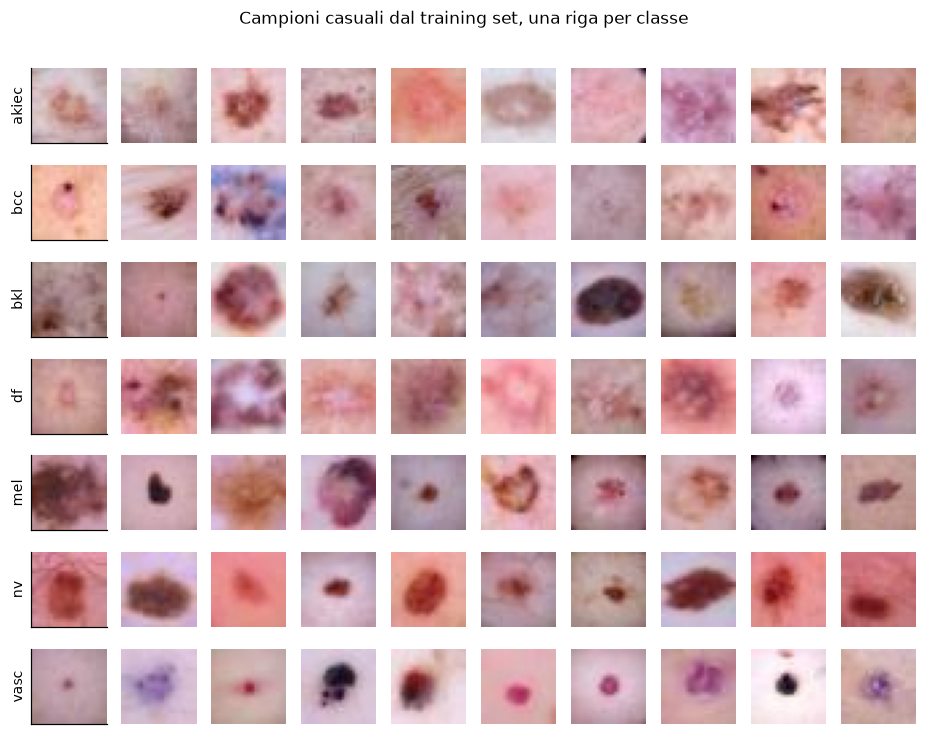

In [15]:
N_SHOW = 10
fig, axes = plt.subplots(N_CLASSES, N_SHOW, figsize=(N_SHOW * 0.85, N_CLASSES * 0.95))
for k in range(N_CLASSES):
    idx = np.where(y["train"] == k)[0]
    pick = rng.choice(idx, size=min(N_SHOW, len(idx)), replace=False)
    for j in range(N_SHOW):
        ax = axes[k, j]; ax.axis("off"); ax.grid(False)
        if j < len(pick):
            ax.imshow(X["train"][pick[j]])
    axes[k, 0].set_ylabel(CLASS_ABBR[k])
    axes[k, 0].axis("on"); axes[k, 0].set_xticks([]); axes[k, 0].set_yticks([]); axes[k, 0].grid(False)
fig.suptitle("Campioni casuali dal training set, una riga per classe", y=1.005)
plt.tight_layout(); plt.show()

In [29]:
## salvo questo campione per fare qualche test
from pathlib import Path
from PIL import Image


output_dir = Path("test_sample_dermamnist")
output_dir.mkdir(parents=True, exist_ok=True)

for k in range(N_CLASSES):

    idx = np.where(y["train"] == k)[0]

    pick = rng.choice(
        idx,
        size=min(N_SHOW, len(idx)),
        replace=False
    )

    for j, image_idx in enumerate(pick):

        image = np.squeeze(X["train"][image_idx])

        filename = output_dir / f"class_{k}_img_{j+1:03d}.png"

        Image.fromarray(
            image.astype(np.uint8)
        ).save(filename)

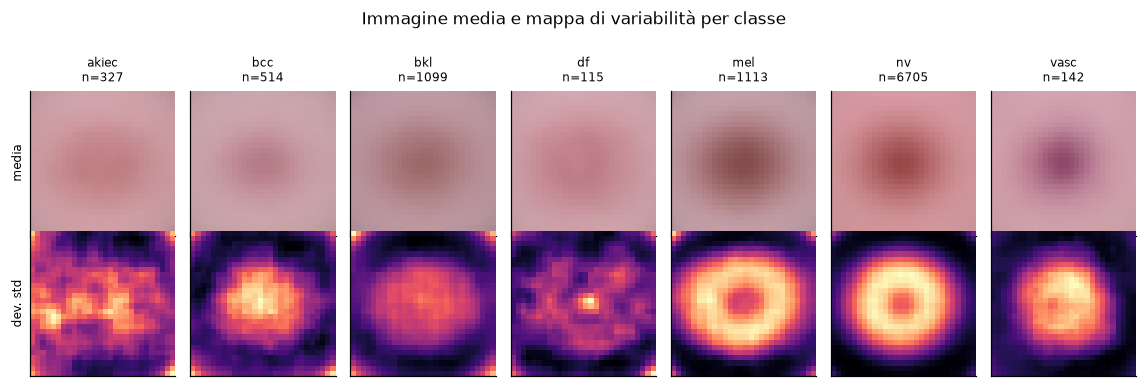

In [17]:
fig, axes = plt.subplots(2, N_CLASSES, figsize=(N_CLASSES * 1.5, 3.4))
for k in range(N_CLASSES):
    m = y_all == k
    mean_img = Xf[m].mean(axis=0)
    std_img = Xf[m].std(axis=0).mean(axis=2)
    axes[0, k].imshow(mean_img); axes[0, k].set_title(f"{CLASS_ABBR[k]}\nn={m.sum()}", fontsize=8)
    im = axes[1, k].imshow(std_img, cmap="magma")
    for r in range(2):
        axes[r, k].set_xticks([]); axes[r, k].set_yticks([]); axes[r, k].grid(False)
axes[0, 0].set_ylabel("media", fontsize=8)
axes[1, 0].set_ylabel("dev. std", fontsize=8)
fig.suptitle("Immagine media e mappa di variabilità per classe", y=1.02)
plt.tight_layout(); plt.show()

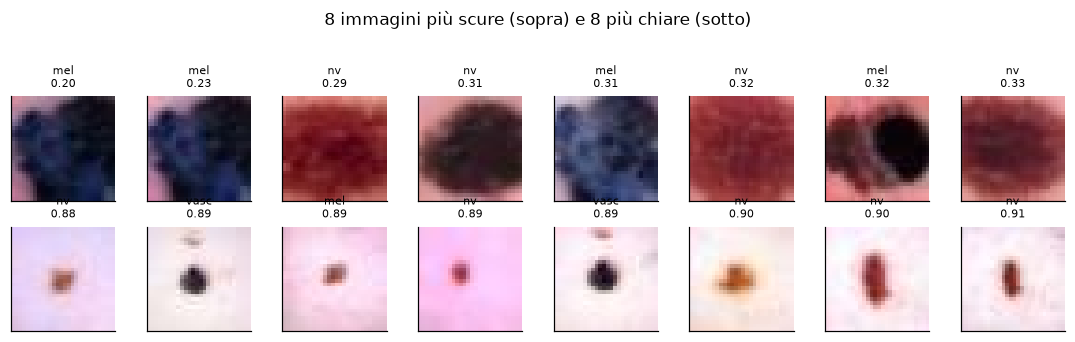

In [18]:
# Casi estremi: immagini più scure e più chiare del dataset (candidati artefatti di acquisizione)
lum = feat["luminosita"].values
order = np.argsort(lum)
sel = np.concatenate([order[:8], order[-8:]])
fig, axes = plt.subplots(2, 8, figsize=(10, 2.9))
for ax, i in zip(axes.ravel(), sel):
    ax.imshow(X_all[i]); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{CLASS_ABBR[y_all[i]]}\n{lum[i]:.2f}", fontsize=7)
fig.suptitle("8 immagini più scure (sopra) e 8 più chiare (sotto)", y=1.05)
plt.tight_layout(); plt.show()

### Cosa emerge

* A **28×28 la lesione è riconoscibile come macchia centrale**, ma i dettagli dermatoscopici (rete
  pigmentaria, globuli, velo blu-bianco) sono irrimediabilmente persi. Anche un dermatologo faticherebbe:
  questo pone un **tetto superiore intrinseco** alle performance ottenibili a questa risoluzione.
* Le immagini medie per classe sono tutte **macchie centrali su fondo chiaro**: la lesione è sistematicamente
  centrata e occupa la porzione centrale del frame. Questo è un **bias di inquadratura** ereditato da HAM10000,
  che il modello sfrutterà (legittimamente, ma va ricordato in caso di deployment su immagini non centrate).
* Le mappe di deviazione standard mostrano variabilità concentrata al centro: i bordi sono uniformemente
  chiari (cute perilesionale) in tutte le classi.
* Fra le immagini estreme compaiono frame molto scuri (vignettatura del dermatoscopio) e molto chiari
  (sovraesposizione): **artefatti di acquisizione**, non patologia. Sono pochi ma suggeriscono che una
  normalizzazione per-immagine possa aiutare la robustezza.

> **Implicazione per l'augmentation (FR-A2):** flip orizzontali/verticali e rotazioni sono **sicuri e
> appropriati** — la lesione è centrata e non ha orientamento canonico. Crop aggressivi sono invece
> rischiosi: a 28×28 taglierebbero via la lesione stessa.

---
## 6. Struttura nello spazio delle feature

Proiettiamo le immagini in bassa dimensione (PCA sui pixel grezzi) per capire se esiste una struttura
di cluster per classe. È una verifica di **quanto il problema sia difficile** nello spazio di input.

Varianza spiegata: PC1 35.8% | prime 2 51.0% | prime 10 85.2% | prime 50 96.5%


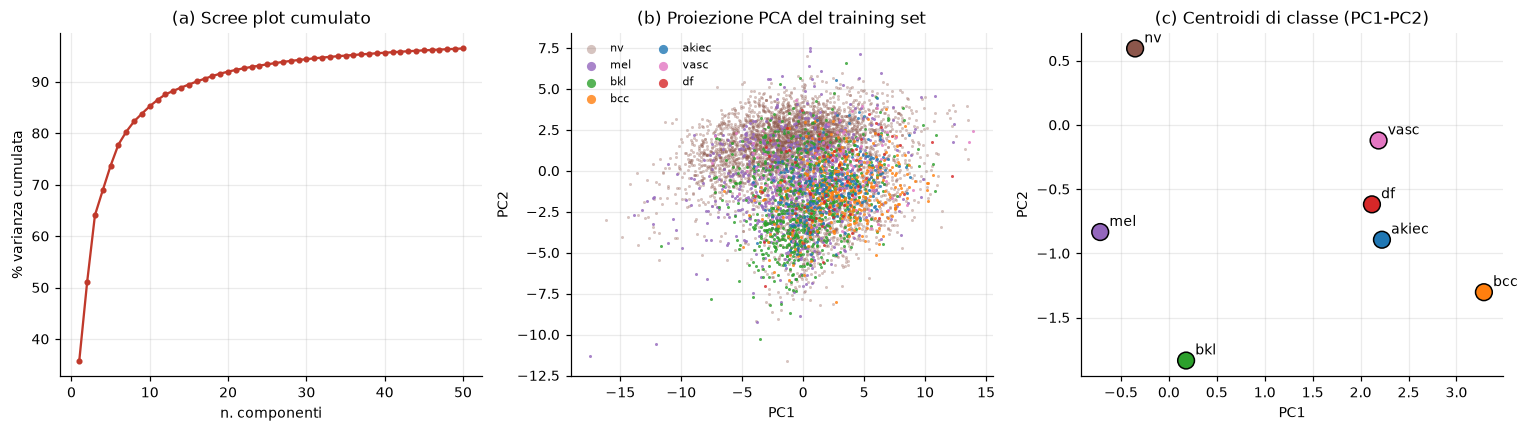

In [19]:
from sklearn.decomposition import PCA

Xtr_flat = X["train"].reshape(len(X["train"]), -1).astype(np.float32) / 255.0
pca = PCA(n_components=50, random_state=RANDOM_STATE).fit(Xtr_flat)
Z = pca.transform(Xtr_flat)

evr = pca.explained_variance_ratio_
print(f"Varianza spiegata: PC1 {evr[0]*100:.1f}% | prime 2 {evr[:2].sum()*100:.1f}% | "
      f"prime 10 {evr[:10].sum()*100:.1f}% | prime 50 {evr.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(np.arange(1, 51), np.cumsum(evr) * 100, "o-", ms=3, color="#c0392b")
ax.set_xlabel("n. componenti"); ax.set_ylabel("% varianza cumulata")
ax.set_title("(a) Scree plot cumulato")

# scatter: classe maggioritaria sotto, classi rare sopra e in evidenza
ax = axes[1]
draw_order = np.argsort([-(y["train"] == k).sum() for k in range(N_CLASSES)])
for k in draw_order:
    m = y["train"] == k
    ax.scatter(Z[m, 0], Z[m, 1], s=4, alpha=0.35 if k == 5 else 0.8,
               color=palette[k], label=CLASS_ABBR[k], linewidths=0)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("(b) Proiezione PCA del training set")
ax.legend(markerscale=3, frameon=False, fontsize=7, ncol=2)

# centroidi di classe: quanto sono separati?
ax = axes[2]
cent = np.stack([Z[y["train"] == k, :2].mean(axis=0) for k in range(N_CLASSES)])
ax.scatter(cent[:, 0], cent[:, 1], c=palette, s=120, edgecolor="k", zorder=3)
for k in range(N_CLASSES):
    ax.annotate(CLASS_ABBR[k], cent[k], xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("(c) Centroidi di classe (PC1-PC2)")

plt.tight_layout(); plt.show()

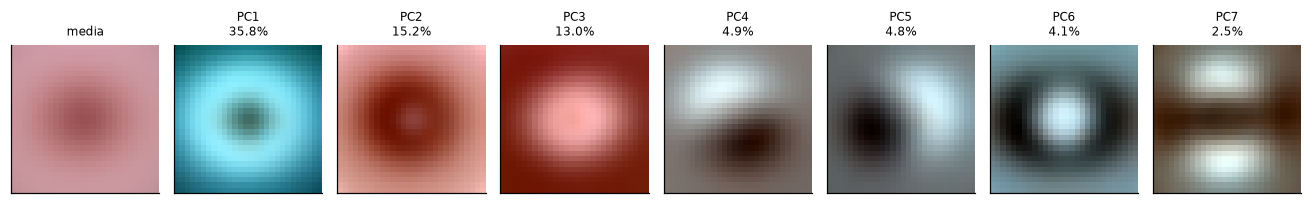

In [20]:
# Prime componenti principali come immagini: cosa cattura la PCA?
fig, axes = plt.subplots(1, 8, figsize=(12, 1.9))
axes[0].imshow(pca.mean_.reshape(28, 28, 3)); axes[0].set_title("media", fontsize=8)
for i in range(7):
    comp = pca.components_[i].reshape(28, 28, 3)
    comp = (comp - comp.min()) / (comp.max() - comp.min())
    axes[i + 1].imshow(comp); axes[i + 1].set_title(f"PC{i+1}\n{evr[i]*100:.1f}%", fontsize=8)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

### Cosa emerge

* La varianza è **estremamente concentrata**: PC1 da sola spiega il **35,8%**, le prime 2 il **51,0%**,
  le prime 10 l'**85,2%** e 50 componenti il **96,5%** dei 2.352 pixel originali. Ma questa varianza è
  **fotometrica, non semantica**: renderizzate come immagini, le prime PC codificano luminosità globale
  e bilanciamento cromatico, non la morfologia della lesione.
* Nello scatter PC1–PC2 le classi sono **completamente sovrapposte**: nessun cluster separabile.
  I centroidi di classe distano poco rispetto alla dispersione intra-classe.

> **Implicazione:** lo spazio dei pixel grezzi non è linearmente separabile. Serve una rappresentazione
> appresa gerarchica (CNN) o pre-addestrata (transfer learning, FR-C3). Questo è anche il motivo per cui
> la baseline lineare della §8 fallisce sulle classi rare.

---
## 7. Qualità dei dati: duplicati, near-duplicate e leakage (FR-D2)

Questa sezione è la più critica per la **validità** dei risultati sperimentali. DermaMNIST eredita da
HAM10000 un problema noto: **più immagini della stessa lesione** (stesso `lesion_id`, acquisizioni
ripetute o a ingrandimenti diversi). Poiché lo split MedMNIST è fatto **per immagine e non per lesione**,
immagini della stessa lesione possono finire sia in train sia in test — gonfiando artificialmente le
performance.

Verifichiamo tre livelli: **duplicati esatti**, **near-duplicate cross-split**, **coerenza delle etichette**.

In [21]:
# --- 7.1 Duplicati esatti (hash dei pixel) ---
def img_hash(a):
    return [hashlib.md5(im.tobytes()).hexdigest() for im in a]

H = {s: img_hash(X[s]) for s in SPLITS}
all_h = sum([H[s] for s in SPLITS], [])
h_counts = Counter(all_h)

n_unique = len(h_counts)
print(f"Immagini totali          : {n_tot}")
print(f"Immagini uniche (hash)   : {n_unique}")
print(f"Copie ridondanti         : {n_tot - n_unique}  ({100*(n_tot-n_unique)/n_tot:.3f}%)")
print(f"Gruppi di duplicati      : {sum(1 for v in h_counts.values() if v > 1)}")

# Coerenza delle etichette all'interno dei gruppi duplicati
pos = {}
for s in SPLITS:
    for i, h in enumerate(H[s]):
        pos.setdefault(h, []).append((s, i))
conflicts = [h for h, lst in pos.items() if len(lst) > 1 and len({int(y[s][i]) for s, i in lst}) > 1]
print(f"Gruppi con etichette in conflitto: {len(conflicts)}")

# --- Leakage esatto cross-split ---
print("\nSovrapposizione esatta fra split:")
for a, b in itertools.combinations(SPLITS, 2):
    inter = set(H[a]) & set(H[b])
    print(f"  {a:>5} ∩ {b:<5}: {len(inter)} immagini")

Immagini totali          : 10015
Immagini uniche (hash)   : 10013
Copie ridondanti         : 2  (0.020%)
Gruppi di duplicati      : 2
Gruppi con etichette in conflitto: 0

Sovrapposizione esatta fra split:
  train ∩ val  : 0 immagini
  train ∩ test : 0 immagini
    val ∩ test : 0 immagini


In [22]:
# --- 7.2 Near-duplicate: nearest neighbour di ogni immagine di test dentro il train ---
def nn_rmse(Q, R, block=512):
    # Per ogni riga di Q: RMSE per pixel rispetto al vicino piu' prossimo in R
    R2 = (R ** 2).sum(axis=1)
    best = np.empty(len(Q), dtype=np.float32)
    arg = np.empty(len(Q), dtype=np.int64)
    for i in range(0, len(Q), block):
        q = Q[i:i + block]
        d2 = (q ** 2).sum(axis=1)[:, None] + R2[None, :] - 2.0 * q @ R.T
        np.maximum(d2, 0, out=d2)
        j = d2.argmin(axis=1)
        best[i:i + block] = np.sqrt(d2[np.arange(len(q)), j])
        arg[i:i + block] = j
    return best / np.sqrt(Q.shape[1]), arg     # RMSE per pixel, indice del vicino

Xte_flat = X["test"].reshape(len(X["test"]), -1).astype(np.float32) / 255.0
Xva_flat = X["val"].reshape(len(X["val"]), -1).astype(np.float32) / 255.0

rmse_te, nn_te = nn_rmse(Xte_flat, Xtr_flat)
rmse_va, nn_va = nn_rmse(Xva_flat, Xtr_flat)

THRESHOLDS = [0.01, 0.02, 0.03, 0.05]
thr_rows = []
for name, r, nn, yq in [("test", rmse_te, nn_te, y["test"]), ("val", rmse_va, nn_va, y["val"])]:
    for t in THRESHOLDS:
        m = r < t
        thr_rows.append({
            "split": name, "soglia_RMSE": t, "n_coppie": int(m.sum()),
            "% dello split": round(100 * m.mean(), 2),
            "accordo_etichette": round(float((yq[m] == y["train"][nn[m]]).mean()), 3) if m.sum() else np.nan,
        })
pd.DataFrame(thr_rows)

,split,soglia_RMSE,n_coppie,% dello split,accordo_etichette
0,test,0.01,0,0.00,NaN
1,test,0.02,8,0.40,1.000
2,test,0.03,18,0.90,0.944
3,test,0.05,427,21.30,0.778
4,val,0.01,0,0.00,NaN
5,val,0.02,4,0.40,1.000
6,val,0.03,14,1.40,1.000
7,val,0.05,224,22.33,0.768


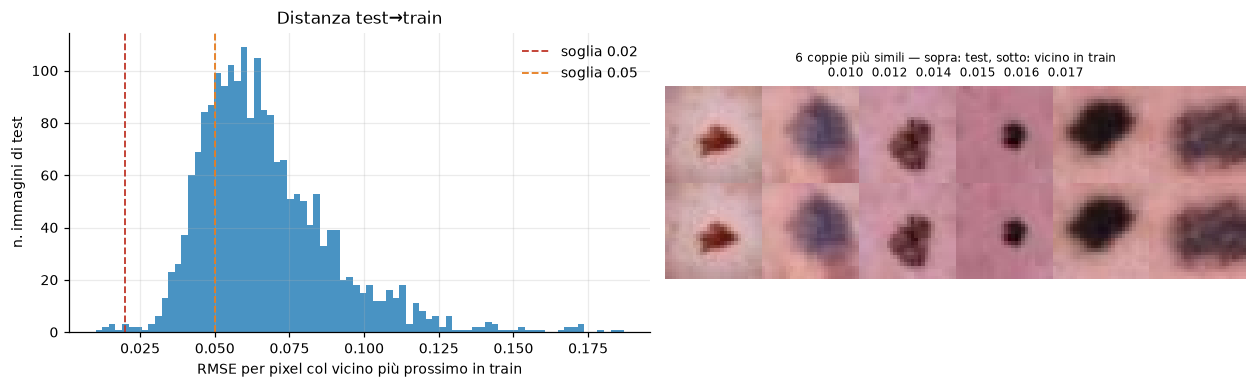

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]
ax.hist(rmse_te, bins=80, color="#2980b9", alpha=0.85)
for t, c in zip([0.02, 0.05], ["#c0392b", "#e67e22"]):
    ax.axvline(t, ls="--", lw=1.2, color=c, label=f"soglia {t}")
ax.set_xlabel("RMSE per pixel col vicino più prossimo in train")
ax.set_ylabel("n. immagini di test")
ax.set_title("Distanza test→train")
ax.legend(frameon=False)

# Le coppie più simili: sono davvero la stessa lesione?
ax = axes[1]; ax.axis("off")
top = np.argsort(rmse_te)[:6]
grid = np.zeros((2 * 28, 6 * 28, 3), dtype=np.uint8)
for j, i in enumerate(top):
    grid[:28, j*28:(j+1)*28] = X["test"][i]
    grid[28:, j*28:(j+1)*28] = X["train"][nn_te[i]]
ax.imshow(grid); ax.grid(False)
ax.set_title("6 coppie più simili — sopra: test, sotto: vicino in train\n"
             + "  ".join(f"{rmse_te[i]:.3f}" for i in top), fontsize=8)

plt.tight_layout(); plt.show()

In [24]:
# Tasso di near-duplicate per classe (soglia conservativa)
T = 0.02
cls_rows = []
for k in range(N_CLASSES):
    m = y["test"] == k
    cls_rows.append({"classe": CLASS_ABBR[k], "n_test": int(m.sum()),
                     "near_dup": int((rmse_te[m] < T).sum()),
                     "%": round(100 * float((rmse_te[m] < T).mean()), 2)})
pd.DataFrame(cls_rows)

,classe,n_test,near_dup,%
0,akiec,66,0,0.00
1,bcc,103,0,0.00
2,bkl,220,1,0.45
3,df,23,0,0.00
4,mel,223,0,0.00
5,nv,1341,7,0.52
6,vasc,29,0,0.00


### Cosa emerge

* **Duplicati esatti: praticamente assenti.** 10.013 immagini uniche su 10.015 → solo **2 copie ridondanti**,
  **0 conflitti di etichetta**, e **0 sovrapposizioni esatte fra gli split**. Lo split ufficiale non contiene
  leakage a livello di pixel identici.
* **Near-duplicate: presenti ma limitati al livello rilevabile.** Nessuna coppia sotto RMSE 0,01;
  con soglia conservativa **RMSE < 0,02** si trovano **8 immagini di test (0,40%)** e 4 di validation
  (0,40%) con un vicino quasi identico nel train, e in questi casi **l'etichetta coincide sempre
  (accordo 1,000)** — comportamento tipico di acquisizioni ripetute della stessa lesione. A 0,03 si sale
  a 18 immagini (0,9%, accordo 0,944). I casi si concentrano su `nv` (7) e `bkl` (1), cioè sulle classi
  più numerose.
* ⚠️ **Limite importante dell'analisi.** A 28×28 la distanza sui pixel **non è un rilevatore affidabile di
  duplicati di lesione**: allargando la soglia a 0,05 si catturerebbe il 21% del test, ma con accordo di
  etichetta di appena ~0,78 — segno che si stanno raccogliendo immagini genericamente simili, non repliche.
  Il downsampling ha distrutto l'informazione necessaria a distinguere i due casi.

> **Conclusione operativa (FR-D2).** L'assenza di duplicati esatti **non basta** a escludere il leakage:
> la letteratura sul dataset (cfr. *Investigating the Quality of DermaMNIST and Fitzpatrick17k*, in
> `docs/references/`) documenta che HAM10000 contiene più immagini per lesione e che lo split MedMNIST,
> essendo per-immagine, le distribuisce fra train e test. La verifica rigorosa richiede i **metadati
> `lesion_id` di HAM10000**, non presenti nell'`.npz`. Due opzioni per il progetto:
>
> 1. **Adottare lo split ufficiale** e documentare esplicitamente il rischio di sovrastima — necessario se
>    si vuole confrontabilità con i numeri pubblicati del benchmark MedMNIST;
> 2. **Ricostruire uno split per-lesione** unendo i metadati HAM10000 (`HAM10000_metadata.csv`) o adottando
>    una variante corretta del dataset (DermaMNIST-C / DermaMNIST-E) — necessario se si vuole una stima
>    **non distorta** della capacità di generalizzazione.
>
> Raccomandazione: **riportare entrambe le valutazioni**, usando lo split ufficiale come baseline
> comparabile e lo split per-lesione come stima onesta.

---
## 8. Baseline di riferimento

Prima di investire in una CNN, fissiamo i numeri da battere. Due riferimenti:
il **classificatore banale** (predice sempre la classe maggioritaria) e una **regressione logistica
sui pixel grezzi**, con e senza riequilibrio delle classi. Servono a calibrare le aspettative e a
dimostrare che l'accuracy da sola è una metrica inutile su questo dataset.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

y_te = y["test"]
results = []

# (0) baseline banale
maj = int(np.bincount(y["train"]).argmax())
p0 = np.full_like(y_te, maj)
results.append({"modello": "maggioritaria (nv)", "accuracy": accuracy_score(y_te, p0),
                "bal_accuracy": balanced_accuracy_score(y_te, p0),
                "macro_F1": f1_score(y_te, p0, average="macro"), "AUC_ovr": np.nan})

# (1)-(2) regressione logistica sui pixel, senza e con class weight
preds = {}
for cw, label in [(None, "logistic (pixel grezzi)"), ("balanced", "logistic + class_weight")]:
    clf = LogisticRegression(max_iter=400, class_weight=cw).fit(Xtr_flat, y["train"])
    p = clf.predict(Xte_flat); proba = clf.predict_proba(Xte_flat)
    preds[label] = p
    results.append({"modello": label, "accuracy": accuracy_score(y_te, p),
                    "bal_accuracy": balanced_accuracy_score(y_te, p),
                    "macro_F1": f1_score(y_te, p, average="macro"),
                    "AUC_ovr": roc_auc_score(y_te, proba, multi_class="ovr")})

pd.DataFrame(results).round(4)

/Users/emanuele/Desktop/esame agentic dottorato/DermaMNIST-agentic_project/DermaMNIST-agentic_project/code/dermaMnist_venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/emanuele/Desktop/esame agentic dottorato/DermaMNIST-agentic_project/DermaMNIST-agentic_project/code/dermaMnist_venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS RE

,modello,accuracy,bal_accuracy,macro_F1,AUC_ovr
0,maggioritaria (nv),0.6688,0.1429,0.1145,NaN
1,logistic (pixel grezzi),0.7007,0.3392,0.3577,0.8613
2,logistic + class_weight,0.5267,0.4756,0.3493,0.8365


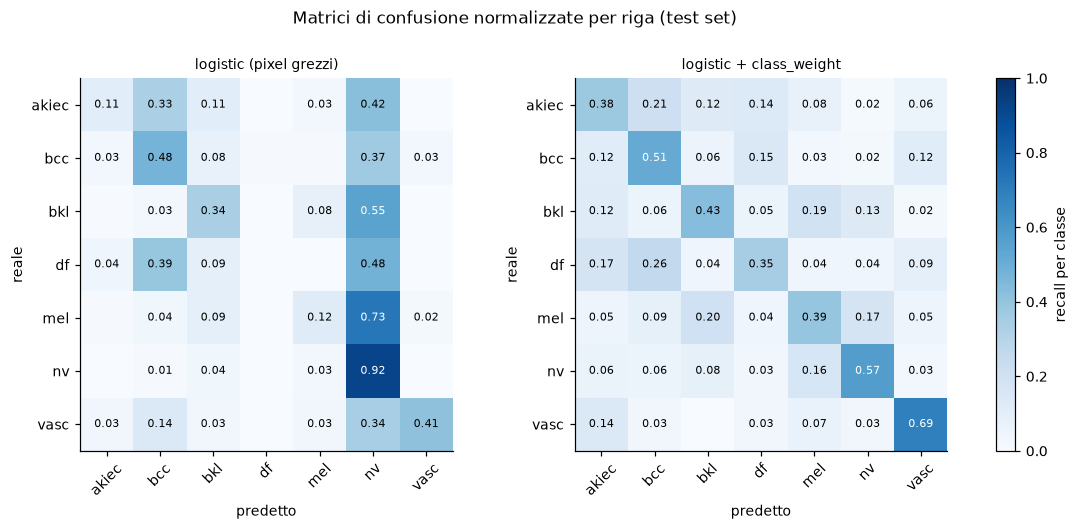

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, (label, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_te, p, labels=range(N_CLASSES), normalize="true")
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(N_CLASSES), CLASS_ABBR, rotation=45)
    ax.set_yticks(range(N_CLASSES), CLASS_ABBR)
    ax.set_xlabel("predetto"); ax.set_ylabel("reale"); ax.set_title(label, fontsize=9)
    ax.grid(False)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            if cm[i, j] > 0.01:
                ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if cm[i, j] > 0.5 else "black")
fig.colorbar(im, ax=axes, fraction=0.025, label="recall per classe")
fig.suptitle("Matrici di confusione normalizzate per riga (test set)", y=1.02)
plt.show()

In [ ]:
print(classification_report(y_te, preds["logistic (pixel grezzi)"],
                            target_names=CLASS_ABBR, digits=3, zero_division=0))

### Cosa emerge

| modello | accuracy | balanced acc. | macro-F1 | AUC-OvR |
|---|---|---|---|---|
| predice sempre `nv` | **0,669** | 0,143 | 0,115 | — |
| logistica su pixel grezzi | 0,701 | 0,339 | 0,358 | 0,861 |
| logistica + `class_weight='balanced'` | 0,527 | **0,476** | 0,349 | 0,837 |

* Il classificatore banale ottiene **66,9% di accuracy** senza imparare nulla. Una CNN che riporti "72% di
  accuracy" starebbe facendo appena meglio di una costante: **l'accuracy va bandita come metrica primaria**.
* La logistica sui pixel supera di poco la baseline banale in accuracy (0,701) ma con balanced accuracy di
  0,339 e **recall nulla su `df`**: sta essenzialmente imparando a dire `nv` (recall 0,922 su `nv`).
* Con `class_weight='balanced'` l'accuracy **cala** a 0,527 mentre la balanced accuracy **sale** a 0,476 e
  tutte le classi ottengono recall > 0,34: è il trade-off che ci si deve aspettare, e la direzione giusta
  per un problema clinico.
* L'**AUC-OvR di 0,861** con un modello lineare indica che un segnale c'è, ma il ranking è molto migliore
  della decisione argmax — segno che **la calibrazione e la scelta delle soglie contano quanto il modello**.

> **Soglie da battere per il classificatore del progetto:** balanced accuracy > 0,48, macro-F1 > 0,36,
> AUC-OvR > 0,86, con **recall su `mel` prioritaria**. Il riferimento di letteratura su DermaMNIST
> (ResNet-18 a 28×28, benchmark MedMNIST v2) è ACC ≈ 0,73 / AUC ≈ 0,92.

---
## 9. Sintesi e implicazioni per il task di classificazione

### 9.1 Scheda sintetica del dataset

| Voce | Valore |
|---|---|
| Immagini totali | 10.015 (train 7.007 / val 1.003 / test 2.005) |
| Formato | 28×28×3 RGB, `uint8`, range [0, 255] |
| Classi | 7 (multi-class, mutuamente esclusive) |
| Classe maggioritaria | `nv` — nei melanocitici, 6.705 (67,0%) |
| Classe minoritaria | `df` — dermatofibroma, 115 (1,15%) |
| Imbalance ratio | 58,3:1 sul totale · 58,7:1 sul solo train |
| Stratificazione degli split | sì (drift ≤ 0,09 pp) |
| Media/std canali (train) | mean [0,7631 0,5381 0,5614] · std [0,1366 0,1543 0,1692] |
| Duplicati esatti | 2 su 10.015 · nessun overlap esatto fra split |
| Near-duplicate test→train (RMSE<0,02) | 8 immagini, 0,4% (accordo etichette 1,000) |
| Baseline banale (accuracy) | 0,669 |
| Baseline lineare (bal. acc / AUC) | 0,476 / 0,861 |

### 9.2 Decisioni progettuali che discendono dall'EDA

**Dati (FR-D1÷D4)**
1. Usare gli **split ufficiali** senza rimescolarli; documentare il rischio di leakage per-lesione e,
   in parallelo, valutare uno **split per-lesione** basato sui metadati HAM10000 (§7).
2. Normalizzare con **statistiche stimate sul solo train**; usare le costanti ImageNet se si adotta un
   backbone pre-addestrato.
3. **Esporre i class weight a valle**: il file JSON prodotto qui sotto è il contratto fra questa EDA e
   gli stage successivi.

**Modello (FR-C1÷C4)**
4. CNN, non feature hand-crafted: le statistiche fotometriche globali non separano le classi (§4, §6).
5. Output **probabilistico calibrato** (FR-C2), non solo argmax: l'AUC alta a fronte di argmax debole
   indica che le soglie decisionali vanno tarate esplicitamente (es. massimizzando la sensibilità su `mel`).
6. Considerare le varianti a **64/128/224 px**: a 28×28 la morfologia diagnostica è persa (§5) e questo
   è probabilmente il vincolo dominante sulle performance (FR-C4).

**Sbilanciamento e augmentation (FR-A1÷A4)**
7. Combinare **class weight / focal loss** con **oversampling** delle classi rare.
8. Augmentation geometrica sicura: **flip H/V e rotazioni a 90°** (lesione centrata, nessun orientamento
   canonico). Evitare crop aggressivi e distorsioni cromatiche forti, che cancellerebbero il segnale di
   policromia (§4, §5).
9. L'augmentation generativa condizionata per classe (FR-A3) ha il suo caso d'uso più forte su
   `df` (80 immagini in train), `vasc` (99) e `akiec` (228).

**Valutazione (FR-V\*)**
10. Metriche primarie: **balanced accuracy, macro-F1, AUC-OvR**, matrice di confusione, e **recall su `mel`**
    come metrica clinica di sicurezza. L'accuracy va riportata solo accanto alla baseline banale (0,669).
11. Con 12 immagini di `df` in validation, la model selection su metriche per-classe è instabile:
    usare metriche aggregate e **intervalli di confidenza bootstrap** sulle classi rare.

In [ ]:
# --- Artefatto per gli stage a valle della pipeline (FR-D3, FR-D4) ---
train_counts = np.bincount(y["train"], minlength=N_CLASSES)
class_weights = len(y["train"]) / (N_CLASSES * train_counts)   # come sklearn 'balanced'

eda_summary = {
    "dataset": "dermamnist",
    "n_classes": N_CLASSES,
    "class_names": CLASS_NAMES,
    "class_abbr": CLASS_ABBR,
    "split_sizes": {s: int(len(y[s])) for s in SPLITS},
    "class_counts": {s: np.bincount(y[s], minlength=N_CLASSES).tolist() for s in SPLITS},
    "imbalance_ratio_train": round(float(train_counts.max() / train_counts.min()), 2),
    "imbalance_ratio_overall": round(float(counts["totale"].max() / counts["totale"].min()), 2),
    "normalization": {
        "computed_on": "train",
        "mean": np.round(TRAIN_MEAN, 6).tolist(),
        "std": np.round(TRAIN_STD, 6).tolist(),
    },
    "class_weights_balanced": np.round(class_weights, 4).tolist(),
    "baselines_test": {r["modello"]: {k: (None if pd.isna(v) else round(float(v), 4))
                                      for k, v in r.items() if k != "modello"} for r in results},
    "data_quality": {
        "exact_duplicates": int(n_tot - n_unique),
        "cross_split_exact_overlap": 0,
        "near_dup_test_rate_rmse002": round(float((rmse_te < 0.02).mean()), 4),
        "note": "Lo split MedMNIST e' per-immagine, non per-lesione: possibile leakage a livello di "
                "lesione non verificabile senza i metadati lesion_id di HAM10000.",
    },
}

path = os.path.join(OUT_DIR, "dermamnist_eda_summary.json")
with open(path, "w") as f:
    json.dump(eda_summary, f, indent=2)

counts.to_csv(os.path.join(OUT_DIR, "class_distribution.csv"))
summary.to_csv(os.path.join(OUT_DIR, "photometric_stats_by_class.csv"))

print("Scritti in", OUT_DIR, ":")
for f_ in sorted(os.listdir(OUT_DIR)):
    print("  -", f_)
print("\nClass weights (balanced):")
for k in range(N_CLASSES):
    print(f"  {CLASS_ABBR[k]:>5}  n_train={train_counts[k]:>4}  weight={class_weights[k]:.3f}")

---
### Riferimenti

* Tschandl P., Rosendahl C., Kittler H. (2018). *The HAM10000 dataset*. Scientific Data 5:180161.
* Yang J. et al. (2023). *MedMNIST v2 — A large-scale lightweight benchmark for 2D and 3D biomedical
  image classification*. Scientific Data 10:41.
* Abhishek K. et al. *Investigating the Quality of DermaMNIST and Fitzpatrick17k Dermatological Image
  Datasets* — copia in `docs/references/`.

# appunti per augmentation

In [ ]:
# │               Fatto misurato (EDA)                │                 Conseguenza sul design dell'augmentation                  │
#  ├───────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
#  │ 7.007 immagini di training per 7 classi           │ dataset piccolo: una CNN overfitta in poche epoche                        │
#  │ fine-grained                                      │                                                                           │
#  ├───────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
#  │ imbalance 58:1 — df 80 img, vasc 99, akiec 228 in │ classi rare di fatto in regime few-shot (FR-A1)                           │
#  │  train                                            │                                                                           │
#  ├───────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
#  │ lesione centrata, nessun orientamento canonico    │ il gruppo diedrale D4 è una simmetria esatta: 8× gratis, rischio zero     │
#  │ (§5)                                              │                                                                           │
#  ├───────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
#  │ saturazione = feature a più alto effect size      │ il ColorJitter standard distruggerebbe il segnale più informativo         │
#  │ (η²=0,131), poi canale R (0,118) (§4)             │                                                                           │
#  ├───────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
#  │ lesione occupa ~10×10 px centrali su 28×28 (§4–5) │ crop/erasing aggressivi tagliano via la lesione stessa                    │
#  ├───────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
#  │ 9,3% immagini con pixel saturi, 4,0% con pixel a  │ variabilità di esposizione reale → jitter fotometrico lieve giustificato; │
#  │ 0 (§3)                                            │  ma i bordi neri sono un artefatto da non introdurre                      │
#  ├───────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
#  │ split per-immagine, non per-lesione:              │ ogni guadagno misurato sullo split ufficiale è in parte misurato su       │
#  │ near-duplicate test→train (§7)                    │ near-duplicate                                                            │
#  └───────────────────────────────────────────────────┴───────────────────────────────────────────────────────────────────────────┘
